# Experiment 5.5.3 — Teacher-weight routing decomposition

Analysis-only notebook. It reads finalized artifacts produced by the Slurm finalizer; it never trains, refits, launches jobs, or regenerates missing runs.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'AGENTS.md').is_file())
root = repo_root / 'notebooks' / 'artifacts' / 'experiment_5_5_3_teacher_weight_routing_decomposition' / 'teacher_weight_routing_decomposition_v1'
required = ['manifest.json', 'teacher_equivalence.csv', 'runs.csv', 'summary.csv', 'paired_deltas.csv', 'recovery.csv', 'logit_distortion.csv', 'weight_drift.csv']
missing = [name for name in required if not (root / name).is_file()]
if missing:
    raise FileNotFoundError(f'Missing finalized Exp5.5.3 artifacts: {missing}')
manifest = json.loads((root / 'manifest.json').read_text(encoding='utf-8'))
equiv = pd.read_csv(root / 'teacher_equivalence.csv')
runs = pd.read_csv(root / 'runs.csv')
summary = pd.read_csv(root / 'summary.csv')
paired = pd.read_csv(root / 'paired_deltas.csv')
recovery = pd.read_csv(root / 'recovery.csv')
distortion = pd.read_csv(root / 'logit_distortion.csv')
weight_drift = pd.read_csv(root / 'weight_drift.csv')
display(pd.DataFrame([manifest]))
display(equiv)
display(summary)

,conditions,equivalence_atol,experiment_id,families,linear_refit,multi_cpu_policy,n_states_by_family,notebook_policy,optimizer,protocol_version,seeds,selection_policy,soft_sigma_multiplier,source_experiment,source_protocol,source_what_frozen
0,"[hard_teacher_frozen, soft_teacher_frozen, har...",0.000001,experiment_5_5_3_teacher_weight_routing_decomp...,"[relative10, fixed250]",train-only StandardScaler + LogisticRegression...,5 teacher tasks -> 30 independent train/evalua...,"{'fixed250': 16, 'relative10': 10}",analysis-only; reads finalized CSV/JSON artifa...,"AdamW(lr=1e-3, weight_decay=1e-4), grad clip 1.0",teacher_weight_routing_decomposition_v1,"[11, 23, 37, 53, 71]",epoch 0 and trained epochs are validation-sele...,1.5,experiment_5_5_non_snn_history_experts,non_snn_history_experts_v1,True


,family,seed,split,max_abs_offline_vs_hard_streaming,predictions_identical
0,relative10,11,train,8.881784e-15,True
1,relative10,11,val,4.440892e-15,True
2,relative10,11,test,3.552714e-15,True
3,relative10,23,train,1.598721e-14,True
4,relative10,23,val,1.065814e-14,True
5,relative10,23,test,1.421085e-14,True
6,relative10,37,train,7.105427e-15,True
7,relative10,37,val,5.329071e-15,True
8,relative10,37,test,7.993606e-15,True
9,relative10,53,train,8.659740e-15,True


,family,condition,n_runs,mean_val_balanced_accuracy,sd_val_balanced_accuracy,mean_test_balanced_accuracy,sd_test_balanced_accuracy,sem_test_balanced_accuracy,mean_test_accuracy,mean_test_macro_f1
0,relative10,hard_teacher_frozen,5,0.631156,0.015002,0.686642,0.038611,0.017267,0.705479,0.690568
1,relative10,soft_teacher_frozen,5,0.566735,0.020246,0.610976,0.028534,0.012761,0.634247,0.611213
2,relative10,hard_random_train,5,0.620895,0.029239,0.627786,0.022284,0.009966,0.639726,0.623063
3,relative10,soft_random_train,5,0.611747,0.014200,0.595073,0.031054,0.013888,0.606849,0.594405
4,relative10,soft_teacher_init_retrain,5,0.612558,0.023294,0.635499,0.035986,0.016093,0.650685,0.630703
5,relative10,soft_linear_refit,5,0.590809,0.024406,0.631584,0.043702,0.019544,0.649315,0.631221
6,fixed250,hard_teacher_frozen,5,0.547346,0.038539,0.595230,0.009826,0.004394,0.608219,0.595250
7,fixed250,soft_teacher_frozen,5,0.495670,0.034916,0.555074,0.039728,0.017767,0.580822,0.546507
8,fixed250,hard_random_train,5,0.561033,0.055826,0.556948,0.030016,0.013424,0.567123,0.549384
9,fixed250,soft_random_train,5,0.600766,0.020816,0.586691,0.016952,0.007581,0.601370,0.579436


## Figure 1 — Complete balanced-accuracy ladder

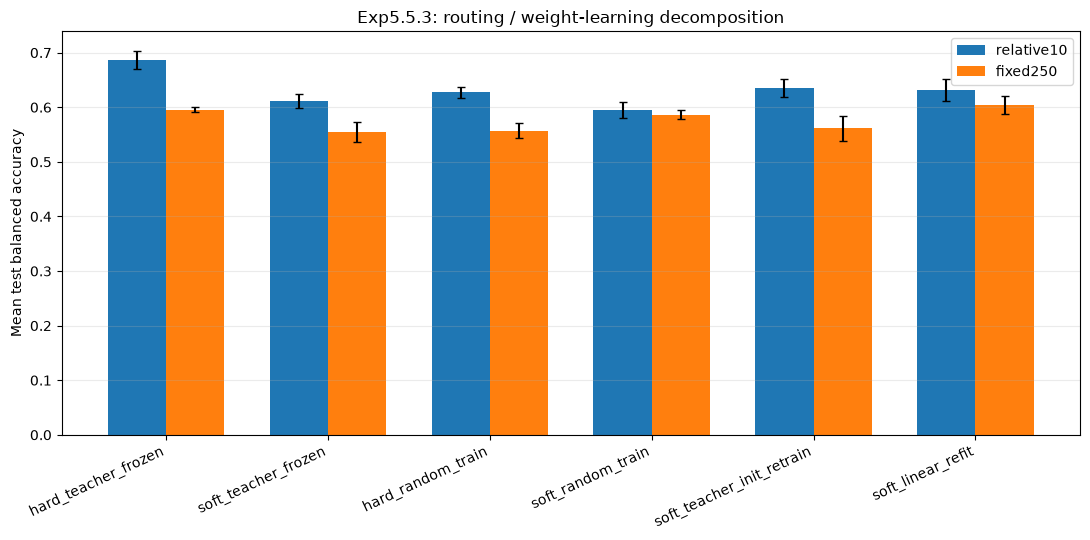

In [2]:
order = ['hard_teacher_frozen', 'soft_teacher_frozen', 'hard_random_train', 'soft_random_train', 'soft_teacher_init_retrain', 'soft_linear_refit']
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(order))
width = 0.36
for offset, family in zip((-width/2, width/2), ('relative10', 'fixed250')):
    values = summary.set_index(['family', 'condition']).loc[[(family, c) for c in order], 'mean_test_balanced_accuracy'].to_numpy()
    errors = summary.set_index(['family', 'condition']).loc[[(family, c) for c in order], 'sem_test_balanced_accuracy'].to_numpy()
    ax.bar(x + offset, values, width=width, yerr=errors, capsize=3, label=family)
ax.set_xticks(x, order, rotation=25, ha='right')
ax.set_ylabel('Mean test balanced accuracy')
ax.set_title('Exp5.5.3: routing / weight-learning decomposition')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Figure 2 — Paired hard-teacher → soft-teacher change

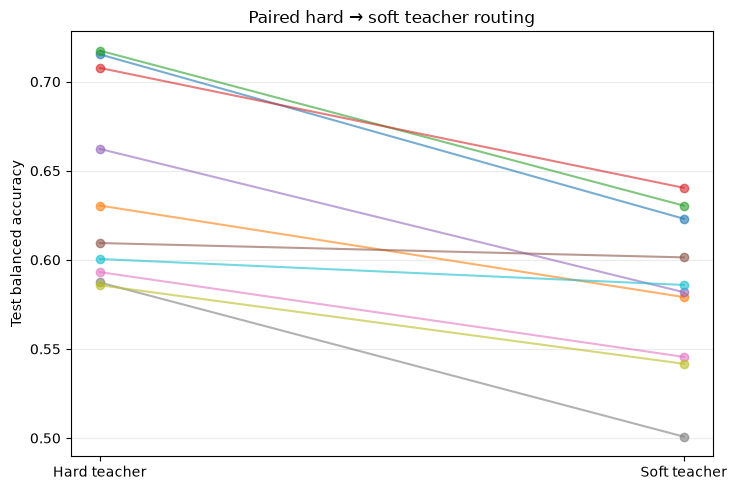

,family,seed,comparison,left_condition,right_condition,delta_test_balanced_accuracy
0,relative10,11,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.092269
7,relative10,23,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.051369
14,relative10,37,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.086986
21,relative10,53,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.067285
28,relative10,71,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.080421
35,fixed250,11,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.008054
42,fixed250,23,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.047567
49,fixed250,37,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.086513
56,fixed250,53,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.044095
63,fixed250,71,softness_penalty,soft_teacher_frozen,hard_teacher_frozen,-0.014552


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))
for family in ('relative10', 'fixed250'):
    subset = runs[(runs.family == family) & runs.condition.isin(['hard_teacher_frozen', 'soft_teacher_frozen'])]
    pivot = subset.pivot(index='seed', columns='condition', values='test_balanced_accuracy')
    for seed, row in pivot.iterrows():
        ax.plot([0, 1], [row['hard_teacher_frozen'], row['soft_teacher_frozen']], marker='o', alpha=0.6)
ax.set_xticks([0, 1], ['Hard teacher', 'Soft teacher'])
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Paired hard → soft teacher routing')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
display(paired[paired.comparison == 'softness_penalty'])

## Figure 3 — Teacher-init retraining recovery

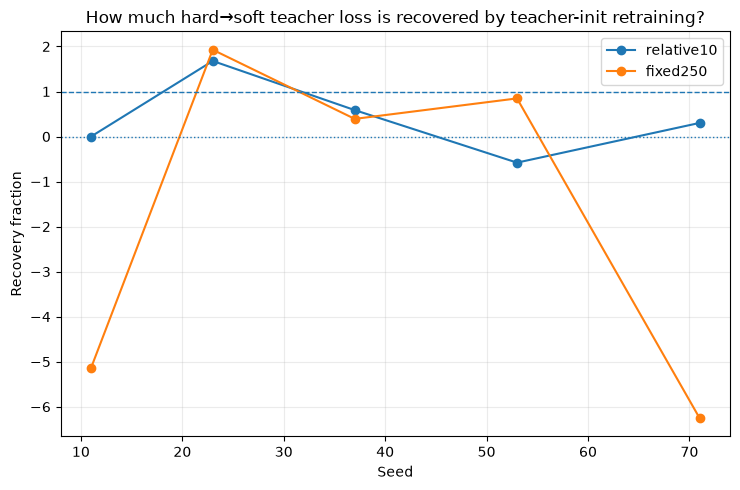

,family,seed,hard_teacher_test_ba,soft_teacher_test_ba,soft_teacher_init_retrain_test_ba,hard_to_soft_loss,retraining_recovery_fraction
0,relative10,11,0.715334,0.623065,0.623065,0.092269,0.000000
1,relative10,23,0.630476,0.579108,0.665311,0.051369,1.678128
2,relative10,37,0.717415,0.630429,0.681507,0.086986,0.587191
3,relative10,53,0.707720,0.640435,0.601453,0.067285,-0.579356
4,relative10,71,0.662266,0.581845,0.606159,0.080421,0.302341
5,fixed250,11,0.609449,0.601395,0.560012,0.008054,-5.138341
6,fixed250,23,0.593132,0.545565,0.637241,0.047567,1.927295
7,fixed250,37,0.587313,0.500800,0.534715,0.086513,0.392027
8,fixed250,53,0.585777,0.541682,0.579020,0.044095,0.846759
9,fixed250,71,0.600482,0.585930,0.494960,0.014552,-6.251335


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))
for family in ('relative10', 'fixed250'):
    part = recovery[recovery.family == family].sort_values('seed')
    ax.plot(part.seed, part.retraining_recovery_fraction, marker='o', label=family)
ax.axhline(1.0, linestyle='--', linewidth=1)
ax.axhline(0.0, linestyle=':', linewidth=1)
ax.set_xlabel('Seed')
ax.set_ylabel('Recovery fraction')
ax.set_title('How much hard→soft teacher loss is recovered by teacher-init retraining?')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
display(recovery)

## Figure 4 — Optimization controls

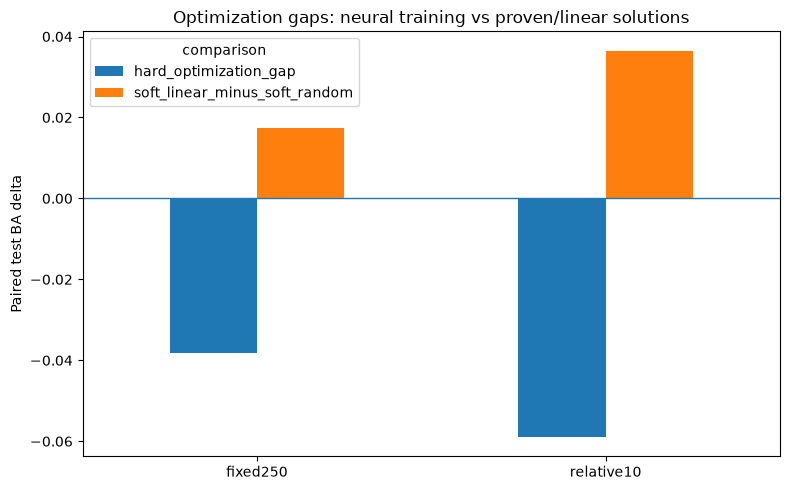

,family,seed,comparison,left_condition,right_condition,delta_test_balanced_accuracy
3,relative10,11,hard_optimization_gap,hard_random_train,hard_teacher_frozen,-0.096152
4,relative10,11,soft_linear_minus_soft_random,soft_linear_refit,soft_random_train,0.076484
10,relative10,23,hard_optimization_gap,hard_random_train,hard_teacher_frozen,0.033969
11,relative10,23,soft_linear_minus_soft_random,soft_linear_refit,soft_random_train,0.052422
17,relative10,37,hard_optimization_gap,hard_random_train,hard_teacher_frozen,-0.095380
18,relative10,37,soft_linear_minus_soft_random,soft_linear_refit,soft_random_train,0.021203
24,relative10,53,hard_optimization_gap,hard_random_train,hard_teacher_frozen,-0.103058
25,relative10,53,soft_linear_minus_soft_random,soft_linear_refit,soft_random_train,0.075034
31,relative10,71,hard_optimization_gap,hard_random_train,hard_teacher_frozen,-0.033661
32,relative10,71,soft_linear_minus_soft_random,soft_linear_refit,soft_random_train,-0.042589


In [5]:
controls = paired[paired.comparison.isin(['hard_optimization_gap', 'soft_linear_minus_soft_random'])].copy()
fig, ax = plt.subplots(figsize=(8.0, 5.0))
means = controls.groupby(['family', 'comparison']).delta_test_balanced_accuracy.mean().unstack()
means.plot(kind='bar', ax=ax)
ax.axhline(0.0, linewidth=1)
ax.set_ylabel('Paired test BA delta')
ax.set_title('Optimization gaps: neural training vs proven/linear solutions')
ax.set_xlabel('')
ax.legend(title='comparison')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
display(controls)

## Figure 5 — Frozen hard→soft logit distortion

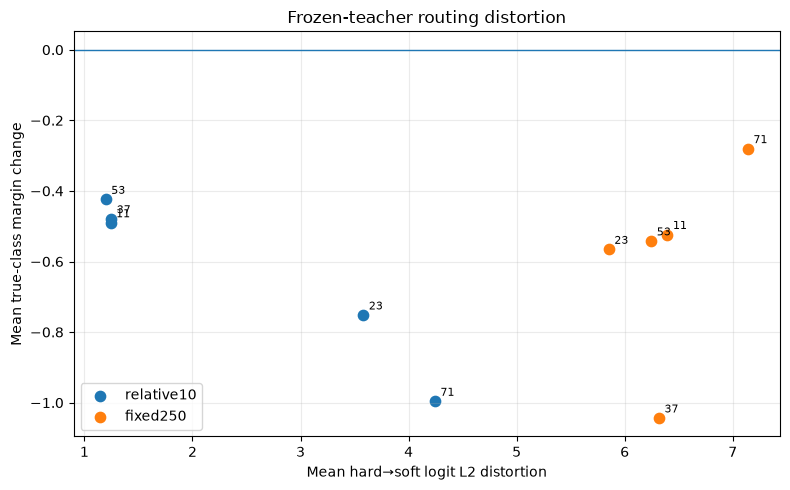

,family,seed,split,mean_logit_abs,mean_logit_l2,mean_true_margin_change,prediction_flip_rate
2,relative10,11,test,0.279236,1.242049,-0.490455,0.178082
5,relative10,23,test,0.821282,3.580696,-0.751836,0.205479
8,relative10,37,test,0.281984,1.247352,-0.479005,0.164384
11,relative10,53,test,0.271429,1.197023,-0.424145,0.095890
14,relative10,71,test,0.961389,4.243364,-0.996318,0.226027
17,fixed250,11,test,1.494566,6.395167,-0.523617,0.315068
20,fixed250,23,test,1.348158,5.852704,-0.565791,0.294521
23,fixed250,37,test,1.467932,6.316471,-1.043646,0.363014
26,fixed250,53,test,1.456815,6.245707,-0.541791,0.321918
29,fixed250,71,test,1.689202,7.139912,-0.280373,0.321918


,family,condition,seed,bias_l2_distance_to_teacher,weight_cosine_to_teacher,weight_frobenius_distance_to_teacher,weight_relative_distance_to_teacher
0,relative10,hard_random_train,11,4.237752,0.290768,3.350073,5.158685
1,relative10,hard_random_train,23,6.525744,0.234943,3.625739,1.701965
2,relative10,hard_random_train,37,4.850592,0.287506,3.358113,5.397010
3,relative10,hard_random_train,53,4.636178,0.228661,3.921867,3.121224
4,relative10,hard_random_train,71,6.268997,0.445732,3.596756,1.571581
5,relative10,soft_random_train,11,4.221405,0.252932,3.446899,5.307786
6,relative10,soft_random_train,23,6.534199,0.117303,3.785133,1.776786
7,relative10,soft_random_train,37,4.840207,0.239792,3.415931,5.489933
8,relative10,soft_random_train,53,4.625716,0.182854,4.221861,3.359975
9,relative10,soft_random_train,71,6.419287,0.213187,3.828930,1.673028


In [6]:
test_dist = distortion[distortion.split == 'test'].copy()
fig, ax = plt.subplots(figsize=(8.0, 5.0))
for family in ('relative10', 'fixed250'):
    part = test_dist[test_dist.family == family].sort_values('seed')
    ax.scatter(part.mean_logit_l2, part.mean_true_margin_change, label=family, s=55)
    for _, row in part.iterrows():
        ax.annotate(str(int(row.seed)), (row.mean_logit_l2, row.mean_true_margin_change), xytext=(4, 4), textcoords='offset points', fontsize=8)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel('Mean hard→soft logit L2 distortion')
ax.set_ylabel('Mean true-class margin change')
ax.set_title('Frozen-teacher routing distortion')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
display(test_dist)
display(weight_drift)